# Feature Engineering: Time Decay & Feature Aggregation
By Akmal


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

def safe_divide(a, b):
    return a / b.replace(0, np.nan)


## Load Data


In [2]:
df = pd.read_csv('../../data_raw_fix/Data_Merged_Fix.csv')

# Standardize columns to match the previous structure
rename_dict = {
    'Video title': 'video_title',
    'Duration': 'duration',
    'Average percentage viewed (%)': 'average_percentage_viewed_pct',
    'Engaged views': 'engaged_views',
    'YouTube Premium (IDR)': 'youtube_premium_idr',
    'Watch Page ads (IDR)': 'watch_page_ads_idr',
    'Estimated AdSense revenue (IDR)': 'estimated_adsense_revenue_idr',
    'YouTube ad revenue (IDR)': 'youtube_ad_revenue_idr',
    'Ad impressions': 'ad_impressions',
    'Playback-based CPM (IDR)': 'playback_based_cpm_idr',
    'CPM (IDR)': 'cpm_idr',
    'Estimated monetized playbacks': 'estimated_monetized_playbacks',
    'RPM (IDR)': 'rpm_idr',
    'Views': 'views',
    'Watch time (hours)': 'watch_time_hours',
    'Subscribers': 'subscribers',
    'Estimated revenue (IDR)': 'estimated_revenue_idr',
    'Impressions': 'impressions',
    'Impressions click-through rate (%)': 'impressions_click_through_rate_pct',
    'Video_ID': 'video_id',
    'TS1_Views': 'ts1_views',
    'TS2_Views': 'ts2_views',
    'TS3_Views': 'ts3_views',
    'TS4_Views': 'ts4_views',
    'Publish_Date_WIB': 'publish_date',
    'Publish_Time_WIB': 'publish_time_wib'
}
df = df.rename(columns=rename_dict)

# Fix missing columns that cause KeyErrors
if 'likes' not in df.columns:
    df['likes'] = df.get('Reactions', 0)
if 'comments' not in df.columns:
    df['comments'] = df.get('Chat messages', 0)
if 'video_duration_sec' not in df.columns:
    df['video_duration_sec'] = df.get('duration', df.get('Duration', 1))


import numpy as np
def parse_duration_to_seconds(val):
    if pd.isna(val) or str(val).strip() == '': return np.nan
    parts = str(val).strip().split(':')
    try:
        parts = [int(p) for p in parts]
        if len(parts) == 3: return parts[0] * 3600 + parts[1] * 60 + parts[2]
        elif len(parts) == 2: return parts[0] * 60 + parts[1]
        return float(parts[0])
    except: return np.nan

if 'Average view duration' in df.columns:
    df['avg_view_duration_sec'] = df['Average view duration'].apply(parse_duration_to_seconds)
    
if 'publish_date' in df.columns:
    df['publish_date'] = pd.to_datetime(df['publish_date'], errors='coerce')

df['publish_date'] = pd.to_datetime(df['publish_date'])


## Part 1 — Time Decay
1. `days_since_upload`
2. `decay_weight = exp(-0.05 * days_since_upload)`
Lambda 0.05 is chosen because YouTube videos typically lose rapid momentum after the first few weeks.
3. `weighted_views = views * decay_weight`


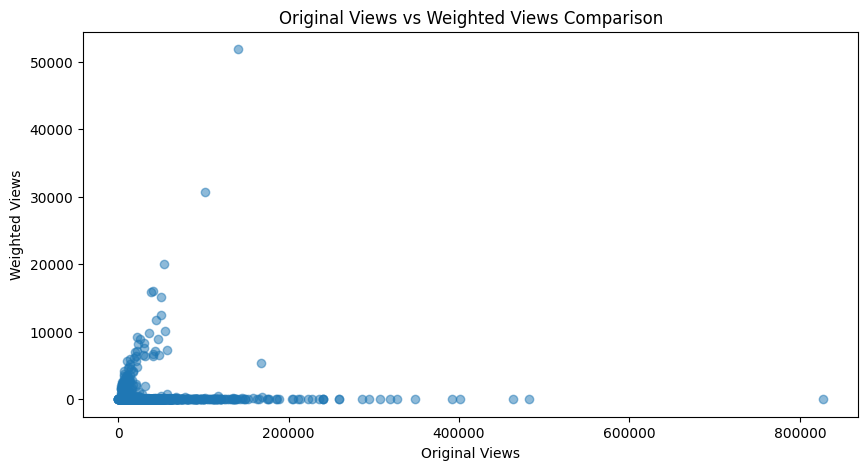

In [3]:
df['days_since_upload'] = (pd.to_datetime('today') - df['publish_date']).dt.days
df['days_since_upload'] = df['days_since_upload'].clip(lower=0)

df['decay_weight'] = np.exp(-0.05 * df['days_since_upload'])
df['weighted_views'] = df['views'] * df['decay_weight']

plt.figure(figsize=(10,5))
plt.scatter(df['views'], df['weighted_views'], alpha=0.5)
plt.xlabel('Original Views')
plt.ylabel('Weighted Views')
plt.title('Original Views vs Weighted Views Comparison')
plt.show()


## Decay Weight Comparison
Plot 3 decay curves using lambda values 0.01, 0.05, 0.1


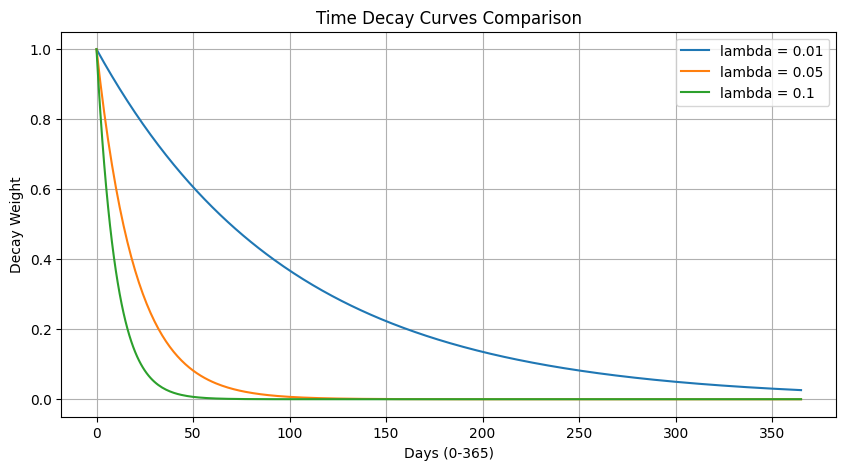

In [4]:
days = np.arange(0, 366)
lambda_1 = np.exp(-0.01 * days)
lambda_2 = np.exp(-0.05 * days)
lambda_3 = np.exp(-0.1 * days)

plt.figure(figsize=(10,5))
plt.plot(days, lambda_1, label='lambda = 0.01')
plt.plot(days, lambda_2, label='lambda = 0.05')
plt.plot(days, lambda_3, label='lambda = 0.1')
plt.xlabel('Days (0-365)')
plt.ylabel('Decay Weight')
plt.title('Time Decay Curves Comparison')
plt.legend()
plt.grid(True)
plt.show()


## Part 2 — Feature Aggregation


In [5]:
df['total_engagement'] = df['engaged_views']
df['engagement_to_view_ratio'] = safe_divide(df['total_engagement'], df['views']).fillna(0)

# Normalize avg_view_duration (min-max scale)
max_dur = df['avg_view_duration_sec'].max()
df['avg_view_duration_norm'] = df['avg_view_duration_sec'] / max_dur if max_dur > 0 else 0

if 'ctr' not in df.columns:
    df['ctr'] = df['impressions_click_through_rate_pct']

df['performance_score'] = (0.4 * df['ctr']) + (0.3 * df['engagement_to_view_ratio']) + (0.3 * df['avg_view_duration_norm'])

top_10 = df.nlargest(10, 'performance_score')[['video_title', 'performance_score']]
display(top_10)


,video_title,performance_score
86,"BARAT GEMPAR! MAYAT TENTARA AS MATI KONYOL, RA...",12.923911
88,DUNIA GEMPAR! IRAN UTUS MALAIKAT MAUT JAGA HOR...,12.825168
113,"NGERI! RATUSAN MAYAT BERSERAKAN DI ISRAEL, KAP...",12.651682
90,"ISRAEL TAMAT! IRAN HANCURKAN JANTUNG TEL AVIV,...",12.563263
101,3500 PASUKAN TENTARA AS MUSNAH SERENTAK! IRAN ...,12.136480
87,"TRUMP DIUSIR PAKSA! 10 JUTA RAKYAT AS NGAMUK, ...",11.830654
1223,DPR MALAYSIA NAIK PITAM! SIAP NYATAKAN PERANG ...,11.808637
111,50 RIBU PASUKAN AS LENYAP! AS PANIK KEHABISAN ...,11.704140
92,QATAR GABUNG IRAN! MEDIA BARAT AKUI ISRAEL HAN...,11.658503
584,"PRABOWO TERBANG KE IRAN, DPR MALAYSIA DESAK AS...",11.591799


## Save Features


In [6]:
cols_to_save = ['video_id', 'days_since_upload', 'decay_weight', 'weighted_views', 'total_engagement', 'engagement_to_view_ratio', 'performance_score']
if 'video_id' in df.columns:
    df[cols_to_save].to_csv('../../data/processed/features_time_decay.csv', index=False)
    print('Saved to features_time_decay.csv')
else:
    print('video_id not found in dataset')


Saved to features_time_decay.csv
